In [30]:

from eval_designs import *
from sequence_extraction import extract_sequences
from data_ingestor import ExperimentManager

from components import plot_rmsd_distributions_overlay, plot_violin_distributions, ViolinParams, plot_rmsd_summary_bars_seaborn


In [31]:
import sys, importlib
if 'components' in sys.modules:
    importlib.reload(sys.modules['components'])
else:
    import components

from components import plot_rmsd_distributions_overlay, plot_violin_distributions, ViolinParams

In [32]:
name = 'position_ablation'

In [33]:
#Import the experiments

em = ExperimentManager()
dfs: list[pd.DataFrame] = em.get_experiments(name=name) 

In [34]:
combined = pd.concat(dfs, ignore_index=True)
 #! ! ! ! ! 
# Ensure that all dfs have exactly the same sample set. If one has samples that another doens't than these will be removed from the other too so that the comparison is fair. A unisue sample is identified by pdb_id + heavy_id, light_id, antigen_id , for one sample ther can exist multiple rows these are variants and are indicated by the sample_id column. Thus we group by the columns that identify a sample and then filter out samples that are not present in all experiments.
sample_id_cols = ['pdb_id', 'heavy_id', 'light_id', 'antigen_id']
sample_counts = combined.groupby(sample_id_cols)['experiment_id'].nunique()
valid_samples = sample_counts[sample_counts == len(dfs)].index
#only keep the rows that are in valid_samples
combined = combined.set_index(sample_id_cols).loc[valid_samples].reset_index()

 

In [35]:
for df in dfs:
    print(len(df))

3672
472
464
464
480
408
392
384
424


In [36]:
pd.set_option('display.max_rows', None)
print(sample_counts)

pdb_id  heavy_id  light_id  antigen_id
1k4c    A         B         C             1
1k4d    A         B         C             9
1r3i    H         L         C             1
1r3j    B         A         C             1
1r3k    B         A         C             1
1r3l    B         A         C             9
1s5h    B         A         C             1
1zwi    A         B         C             1
2atk    A         B         C             1
2bob    A         B         C             1
2boc    A         B         C             9
2dwd    A         B         C             1
2dwe    A         B         C             1
2h8p    A         B         C             1
2hfe    A         B         C             1
2hg5    A         B         C             1
2hjf    A         B         C             9
2hvj    A         B         C             1
2hvk    A         B         C             1
2ih1    A         B         C             1
2ih3    A         B         C             1
2itc    A         B         C        

In [37]:
#set display back to default
pd.reset_option('display.max_rows')
combined

,pdb_id,heavy_id,light_id,antigen_id,experiment_id,sample_id,sample_step,cdr_target,timestamp,reference_pdb_rpath,...,result_dir,uid,rmsd,ar,aar,ll,pll,ll_perplexity,pll_perplexity,sequences
0,1k4d,A,B,C,v2_base_cdrh3_testset_no_sb,0,100,H_CDR3,2025_08_18__23_10_32,0053_1k4d_A_B_C_2025_08_18__23_10_32/reference...,...,/simonvermeir/DGAD/models/diffab-main-edit-1/r...,v2_base_cdrh3_testset_no_sb___1k4d___A_B_C___0...,1.103725,7.0,0.777778,-31.295307,-15.319495,1.303711,5.485817,{'reference': {'chain_id_to_chain_idx': {'A': ...
1,1k4d,A,B,C,v2_base_cdrh3_testset_no_sb,1,100,H_CDR3,2025_08_18__23_10_32,0053_1k4d_A_B_C_2025_08_18__23_10_32/reference...,...,/simonvermeir/DGAD/models/diffab-main-edit-1/r...,v2_base_cdrh3_testset_no_sb___1k4d___A_B_C___1...,1.549923,5.0,0.555556,-27.833176,-15.424768,1.266015,5.550362,{'reference': {'chain_id_to_chain_idx': {'A': ...
2,1k4d,A,B,C,v2_base_cdrh3_testset_no_sb,2,100,H_CDR3,2025_08_18__23_10_32,0053_1k4d_A_B_C_2025_08_18__23_10_32/reference...,...,/simonvermeir/DGAD/models/diffab-main-edit-1/r...,v2_base_cdrh3_testset_no_sb___1k4d___A_B_C___2...,1.758888,7.0,0.777778,-29.203730,-17.828416,1.280806,7.249519,{'reference': {'chain_id_to_chain_idx': {'A': ...
3,1k4d,A,B,C,v2_base_cdrh3_testset_no_sb,3,100,H_CDR3,2025_08_18__23_10_32,0053_1k4d_A_B_C_2025_08_18__23_10_32/reference...,...,/simonvermeir/DGAD/models/diffab-main-edit-1/r...,v2_base_cdrh3_testset_no_sb___1k4d___A_B_C___3...,1.536936,7.0,0.777778,-34.318794,-20.735566,1.337547,10.013676,{'reference': {'chain_id_to_chain_idx': {'A': ...
4,1k4d,A,B,C,v2_base_cdrh3_testset_no_sb,4,100,H_CDR3,2025_08_18__23_10_32,0053_1k4d_A_B_C_2025_08_18__23_10_32/reference...,...,/simonvermeir/DGAD/models/diffab-main-edit-1/r...,v2_base_cdrh3_testset_no_sb___1k4d___A_B_C___4...,1.407772,4.0,0.444444,-28.952736,-19.772046,1.278084,8.997025,{'reference': {'chain_id_to_chain_idx': {'A': ...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2659,7tat,H,L,A,sims_pos_fixed_aux_from_scratch_target_cdrh3_n...,3,100,H_CDR3,2025_07_31__19_03_06,0059_7tat_H_L_A_2025_07_31__19_03_06/reference...,...,/simonvermeir/DGAD/models/diffab-main-edit-1/r...,sims_pos_fixed_aux_from_scratch_target_cdrh3_n...,3.497427,9.0,0.692308,-24.641579,-34.416102,1.227950,14.117180,{'reference': {'chain_id_to_chain_idx': {'H': ...
2660,7tat,H,L,A,sims_pos_fixed_aux_from_scratch_target_cdrh3_n...,4,100,H_CDR3,2025_07_31__19_03_06,0059_7tat_H_L_A_2025_07_31__19_03_06/reference...,...,/simonvermeir/DGAD/models/diffab-main-edit-1/r...,sims_pos_fixed_aux_from_scratch_target_cdrh3_n...,5.325927,10.0,0.769231,-22.963650,-29.157237,1.210900,9.420276,{'reference': {'chain_id_to_chain_idx': {'H': ...
2661,7tat,H,L,A,sims_pos_fixed_aux_from_scratch_target_cdrh3_n...,5,100,H_CDR3,2025_07_31__19_03_06,0059_7tat_H_L_A_2025_07_31__19_03_06/reference...,...,/simonvermeir/DGAD/models/diffab-main-edit-1/r...,sims_pos_fixed_aux_from_scratch_target_cdrh3_n...,2.677089,9.0,0.692308,-23.882973,-27.250144,1.220212,8.134912,{'reference': {'chain_id_to_chain_idx': {'H': ...
2662,7tat,H,L,A,sims_pos_fixed_aux_from_scratch_target_cdrh3_n...,6,100,H_CDR3,2025_07_31__19_03_06,0059_7tat_H_L_A_2025_07_31__19_03_06/reference...,...,/simonvermeir/DGAD/models/diffab-main-edit-1/r...,sims_pos_fixed_aux_from_scratch_target_cdrh3_n...,3.214932,9.0,0.692308,-25.985023,-29.460296,1.241775,9.642465,{'reference': {'chain_id_to_chain_idx': {'H': ...


In [38]:
# Group by experiment (support if multiple experiment_ids per df)
metrics = ['rmsd']
group = combined.groupby('experiment_id', dropna=False)[metrics]
agg = group.agg(['mean', 'std', 'min', 'max'])
agg

rmsd            \
                                                        mean       std   
experiment_id                                                            
sims_pos_fixed_aux_from_base_target_cdrh3_no_sb...  3.342723  2.136919   
sims_pos_fixed_aux_from_base_target_cdrh3_no_sb...  3.290876  2.024921   
sims_pos_fixed_aux_from_base_target_cdrh3_no_sb...  3.298647  2.027613   
sims_pos_fixed_aux_from_base_target_cdrh3_no_sb...  3.415146  2.230674   
sims_pos_fixed_aux_from_scratch_target_cdrh3_no...  3.343511  2.156691   
sims_pos_fixed_aux_from_scratch_target_cdrh3_no...  3.352163  2.167941   
sims_pos_fixed_aux_from_scratch_target_cdrh3_no...  3.448580  2.289674   
sims_pos_fixed_aux_from_scratch_target_cdrh3_no...  3.727223  2.726616   
v2_base_cdrh3_testset_no_sb                         3.620562  3.178500   

                                                                         
                                                         min        max  
experiment_id                                                            
sims_pos_fixed_aux_from_base_target_cdrh3_no_sb...  0.659669  12.577229  
sims_pos_fixed_aux_from_base_target_cdrh3_no_sb...  0.624394  12.774605  
sims_pos_fixed_aux_from_base_target_cdrh3_no_sb...  0.620086  13.431301  
sims_pos_fixed_aux_from_base_target_cdrh3_no_sb...  0.545007  16.046545  
sims_pos_fixed_aux_from_scratch_target_cdrh3_no...  0.673517  12.790223  
sims_pos_fixed_aux_from_scratch_target_cdrh3_no...  0.739125  13.257543  
sims_pos_fixed_aux_from_scratch_target_cdrh3_no...  0.805153  14.105714  
sims_pos_fixed_aux_from_scratch_target_cdrh3_no...  0.757915  15.716627  
v2_base_cdrh3_testset_no_sb                         0.699755  40.122767

In [43]:
# Extract all unique experiment IDs from combined and create a template rename dict
experiment_ids = combined['experiment_id'].unique()
rename_template = {exp_id: "" for exp_id in experiment_ids}

import json
print(json.dumps(rename_template, indent=4))

{
    "v2_base_cdrh3_testset_no_sb": "",
    "sims_pos_fixed_aux_from_base_target_cdrh3_no_sb_testset_gs-0-5": "",
    "sims_pos_fixed_aux_from_base_target_cdrh3_no_sb_testset_gs-0-75": "",
    "sims_pos_fixed_aux_from_base_target_cdrh3_no_sb_testset_gs-1-0": "",
    "sims_pos_fixed_aux_from_base_target_cdrh3_no_sb_testset_gs-1-5": "",
    "sims_pos_fixed_aux_from_scratch_target_cdrh3_no_sb_testset_gs-0-5": "",
    "sims_pos_fixed_aux_from_scratch_target_cdrh3_no_sb_testset_gs-0-75": "",
    "sims_pos_fixed_aux_from_scratch_target_cdrh3_no_sb_testset_gs-1-0": "",
    "sims_pos_fixed_aux_from_scratch_target_cdrh3_no_sb_testset_gs-1-5": ""
}


In [44]:
rename_dict = {
    "v2_base_cdrh3_testset_no_sb": "baseline",
    "sims_pos_fixed_aux_from_base_target_cdrh3_no_sb_testset_gs-0-5": "from base pos guidance 0.5",
    "sims_pos_fixed_aux_from_base_target_cdrh3_no_sb_testset_gs-0-75": "from base pos guidance 0.75",
    "sims_pos_fixed_aux_from_base_target_cdrh3_no_sb_testset_gs-1-0": "from base pos guidance 1.0",
    "sims_pos_fixed_aux_from_base_target_cdrh3_no_sb_testset_gs-1-5": "from base pos guidance 1.5",
    "sims_pos_fixed_aux_from_scratch_target_cdrh3_no_sb_testset_gs-0-5": "from scratch pos guidance 0.5",
    "sims_pos_fixed_aux_from_scratch_target_cdrh3_no_sb_testset_gs-0-75": "from scratch pos guidance 0.75",
    "sims_pos_fixed_aux_from_scratch_target_cdrh3_no_sb_testset_gs-1-0": "from scratch pos guidance 1.0",
    "sims_pos_fixed_aux_from_scratch_target_cdrh3_no_sb_testset_gs-1-5": "from scratch pos guidance 1.5"
}

In [46]:
#we now have combined with all experiments and we can plot the violin plots we extract a new df for each experiment and put them in a dict we extract this from combined for every experiment_id
exps = {}
for exp_id in combined['experiment_id'].unique():
    exps[exp_id] = combined[combined['experiment_id'] == exp_id]


params = ViolinParams(value_column=['rmsd'], show_points=False, show_whiskers=False)
fig = plot_violin_distributions(
    exps,
    cdr_target='H_CDR3',
    title='RMSD Violin',
    params=params,
    height=1200,
    confidence_level=1.0,
    rename_dict= rename_dict
)

In [40]:
fig = plot_rmsd_distributions_overlay(
    exps, 
    cdr_target='H_CDR3',
    title="RMSD Distribution Comparison - Full Data",
    value_column='rmsd',  # Default, can be omitted
    show_histogram=True,
    show_kde=True,
    fill_kde=True,
    use_probability_density=True,
    nbins=40,
    value_range=(0,30)
)


v2_base_cdrh3_testset_no_sb - Range filtering [0, 30]: 296 → 295 samples

sims_pos_fixed_aux_from_base_target_cdrh3_no_sb_testset_gs-0-5 - Range filtering [0, 30]: 296 → 296 samples

sims_pos_fixed_aux_from_base_target_cdrh3_no_sb_testset_gs-0-75 - Range filtering [0, 30]: 296 → 296 samples

sims_pos_fixed_aux_from_base_target_cdrh3_no_sb_testset_gs-1-0 - Range filtering [0, 30]: 296 → 296 samples

sims_pos_fixed_aux_from_base_target_cdrh3_no_sb_testset_gs-1-5 - Range filtering [0, 30]: 296 → 296 samples

sims_pos_fixed_aux_from_scratch_target_cdrh3_no_sb_testset_gs-0-5 - Range filtering [0, 30]: 296 → 296 samples

sims_pos_fixed_aux_from_scratch_target_cdrh3_no_sb_testset_gs-0-75 - Range filtering [0, 30]: 296 → 296 samples

sims_pos_fixed_aux_from_scratch_target_cdrh3_no_sb_testset_gs-1-0 - Range filtering [0, 30]: 296 → 296 samples

sims_pos_fixed_aux_from_scratch_target_cdrh3_no_sb_testset_gs-1-5 - Range filtering [0, 30]: 296 → 296 samples

v2_base_cdrh3_testset_no_sb Final Stati

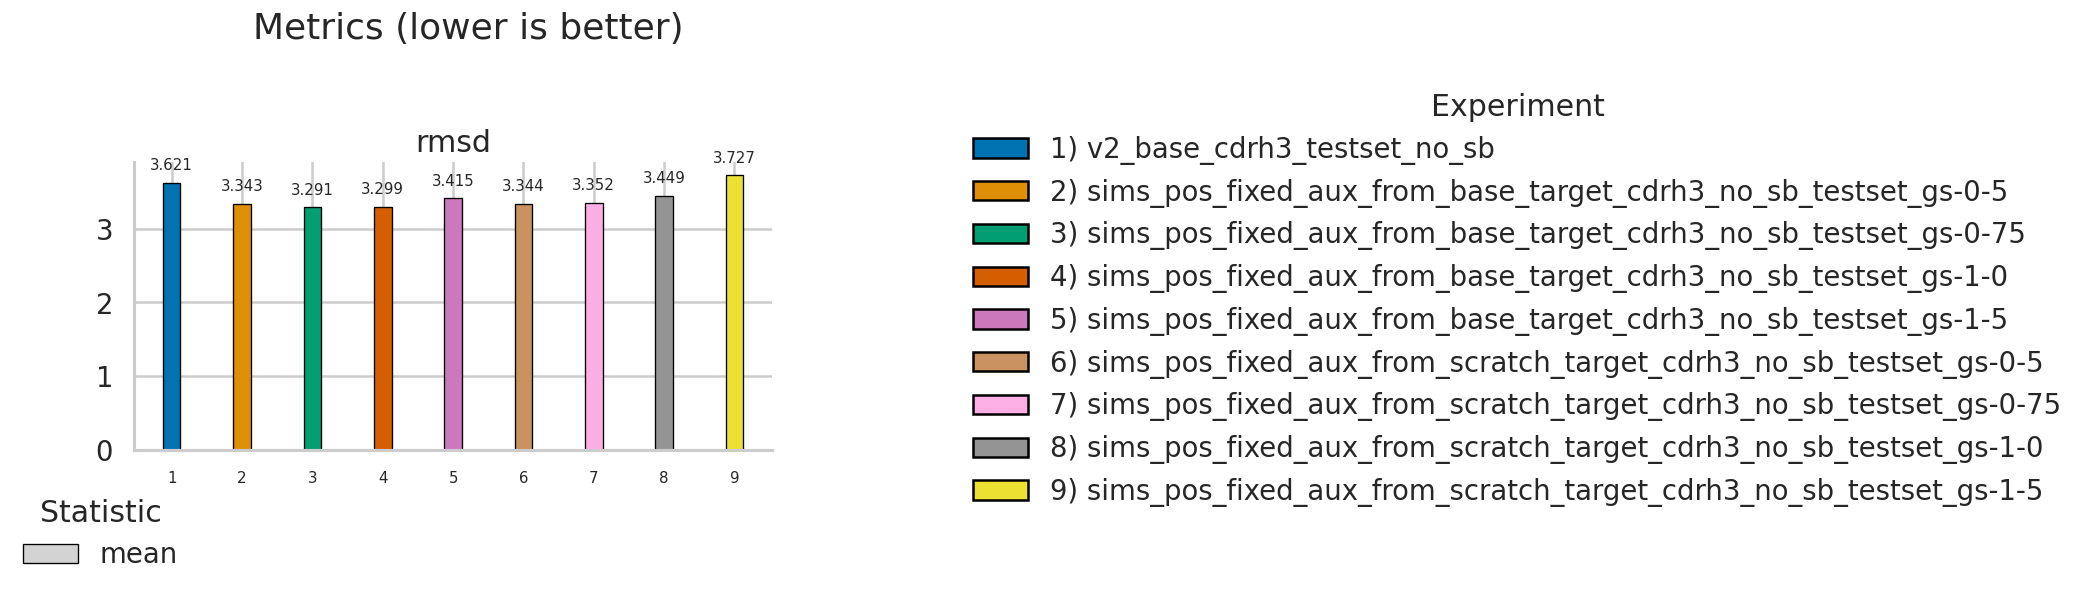

In [41]:
fig = plot_rmsd_summary_bars_seaborn(
    exps,
    cdr_target="H_CDR3",
    title="Metrics (lower is better)",
    value_columns=("rmsd"),   # or multiple metrics for side-by-side subplots
    confidence_level=0.95,
    cap_percentile=0.95,
    errorbar_percentiles=(5, 95),
    reverse_y=False,
    show_mean_errorbars=False,
    show_min_max_bars=False,
    show_experiment_names=False,
    show_mean_value=True,
    show_extrema_markers=False,  # if None, falls back to show_outlier_markers
    magnify=False,
    show_yaxis_label=False


)
# plt.show()  # if not already showing elsewhere


In [42]:
fig.savefig("pos.pdf", bbox_inches="tight") 